<div style="text-align: right"><img src="https://www.haskoning.com/-/media/project/common/haskoning-logo.svg" align="right" valign="top" style="margin: 0px 0px 10px 10px;" width=300></div>

<font size=20>D-Hydro to ISG</font>
<a class="anchor" id="stap0"></a>

Dhydro2ISG is a Python package that can extract data from a D-Hydro model to input for a groundwater model in ISG format. The package is developed by Haskoning and made open-source with financial support of waterboard De Dommel. 

#### Workflow 
The workflow to create an ISG file based on D-Hydro model is as follows:
1. Define input
2. Extract data from D-Hydro model 
3. Export to ISG

Optionally you can:
- Export the standardized data to shape, edit the data in GIS and import it again
- Import ISG files

#### ISG Support
The tool creates an ISG file without support for surface-flow routing (ASFR=0). This ISG file contains the following parameters:

| Parameter       | Description                                                            | Source |
|-------------|------------------------------------------------------------------------|-----|
| Water level | The water level at the calculation node for defined period                               | D-Hydro model |
| Bottom level| The bottom level at the calculation node                               | D-Hydro model |
| Resistance  | The resistance of the river bed at the calculation node (days)                                | Manual input |
| Inf.factor  | The infiltration factor at the calculation node (-)                       | Manual input |
| mrc  | Manning’s Resistance Coefficient MRC for the cross-section (-)                       | Manual input |

 

Q-H relationships and structures are not supported. 


#### Notes
Note that the code is tested for a limited amount of D-Hydro models and therefore it is required to validate the output before using it. The code is tested for D-Hydro versions XX, XX, 2025.01 and 2025.03. 

The package is open-source so if you miss functionality you can create a new branch on github and propose a solution. If you experience a bug you can create an issue in github and preferable also propose a solution.  

This tool depends on hydrolib-core. If the model version is not supported by hydrolib core this could raise an error. This is a known issue. 

## Input

In [1]:
import os
from dhydro2isg.dhydro2isg import dhydro_to_stf
from dhydro2isg.stf import STF

In [21]:
path_dhydro_model = r"c:\Users\905872\Haskoning\P-BK8839-WSVV-detachering-hydroloog - Team\WIP\01_modelbouw\Modellen\C Boven-heigraaf\Oud\T10_1D_1912_v0.18_basis\T10_1D_1912_v0.18_basis.dsproj_data\DFM" # Path to the D-HYDRO model folder

start_time = "2000-01-1" # format: YYYY-MM-DD
end_time = "2000-01-10" # format: YYYY-MM-DD

# Uniform parameters for all calculation points and segments
resistance = 1 #  Uniform Resistance of the riverbed (days).
infiltration = 0.3 # Uniform infiltration coefficient for all calculation points
mrc = 0.02 # Uniform manning resistance coefficient for all segments

output_folder = r"c:\Users\905872\Downloads\temp\test_20260106"

# Change the relative paths for the following D-Hydro files only if they are not in the default location
# relpath_network_nc = 'fm/network.nc' 
# relpath_map_nc = 'fm/output/DFM_map.nc' 
# relpath_crossloc_ini = 'fm/crsloc.ini' 
# relpath_crossdef_ini = 'fm/crsdef.ini' 

relpath_network_nc = 'input/Vallei_net.nc' 
relpath_map_nc = 'output/DFM_map.nc' 
relpath_crossloc_ini = 'input/cross_section_locations.ini' 
relpath_crossdef_ini = 'input/cross_section_definitions.ini' 

## Extract data from D-Hydro model 
In this step the relevant data is extracted from the D-Hydro model and converted to a standardized table format (STF). For the resistance, infiltration and manning roughness a uniform value is applied.

In [22]:
stf = dhydro_to_stf(dhydro_folder=path_dhydro_model,
                    start_time=start_time,
                    end_time=end_time,
                    resistance=resistance,
                    infiltration=infiltration,
                    mrc=mrc,
                    relpath_network_nc=relpath_network_nc,
                    relpath_map_nc=relpath_map_nc,
                    relpath_crossloc_ini=relpath_crossloc_ini,
                    relpath_crossdef_ini=relpath_crossdef_ini,
                    )

import succeeded


You can discover (and edit if you want) the extracted data in the SFT with the following functions:
- `stf.segments`
- `stf.locations`
- `stf.calculation_points`
- `stf.cross_sections`

For example:

<Axes: >

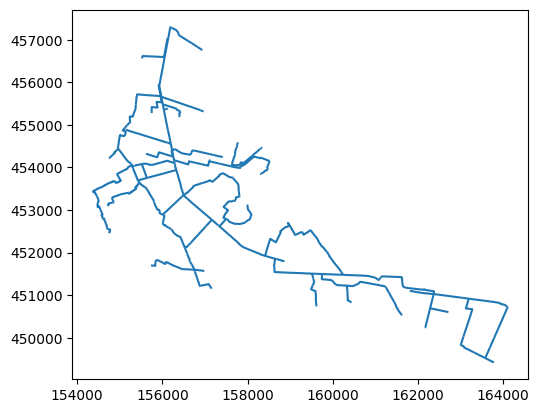

In [6]:
stf.segments.plot()

In [30]:
stf.calculation_points.index.get_level_values(0).tolist()

['WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_113322',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105102',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_0.00WL_105885',
 'WL_113322_2.49WL_105103',
 'WL_113322_2.49WL_105103',
 'WL_113322_2.49WL_105103',
 'WL_113322_2.49WL_105103',
 'WL_113322_2.49WL_105103',
 'WL_113322_2.49WL_1

In [31]:
label = stf.calculation_points.index.get_level_values(0)[0]
stf.calculation_points.xs("WL_113319_0.00WL_113319", level=0)



,wlvl,btml,resis,inff
datetime,,,,
2000-01-01,5.400884,4.331,1,0.3
2000-01-02,5.400884,4.331,1,0.3
2000-01-03,5.400884,4.331,1,0.3
2000-01-04,5.400884,4.331,1,0.3
2000-01-05,5.400884,4.331,1,0.3
2000-01-06,5.400884,4.331,1,0.3
2000-01-07,5.400884,4.331,1,0.3
2000-01-08,5.400884,4.331,1,0.3
2000-01-09,5.400884,4.331,1,0.3


## Export to ISG
Export the converted data to ISG format

In [ ]:
stf.export_to_isg(export_folder=output_folder, filename='test_output_isg')

## Additional functionality

### Export to and import from shapes
You can export the converted data to shapes and load it again. With this option is it possible to edit the data in GIS.  

**Export to shapes**

In [32]:
export_folder = os.path.join(output_folder, 'shape_export') # Path where the shape files will be saved
filename_export = 'stf_export' # Name of the shape file without extension

stf.export_to_shape(export_folder, filename_export)

Export completed


**Import from shapes**

In [ ]:
updated_STF = STF() # Create a new STF object
updated_STF.import_from_shape(export_folder, filename_export) # Import the shape files into the new STF object. Change the export folder and filename as needed.

### Import from ISG
It is also possible to load an ISG. This will overwrite the tables in memory. Therefore it is adviced to create a new empty STF object.

In [ ]:
filepath_isg = output_folder # path to the folder where the ISG files are saved

other_stf=STF()
other_stf.import_isg(filepath_isg)